<a href="https://colab.research.google.com/github/bahador1/BahadorColabNotes/blob/main/continual_learning_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Continual learning: learn new skills without losing old ones


We train a small neural network sequentially:
1. **Task A:** recognize digits 0–4.
2. **Task B:** recognize digits 5–9.

The model always has ten output classes and must choose among all ten, without being told which task a test image belongs to. This is a small **class-incremental learning** example. The tasks are compatible: learning B does not require changing the correct labels of A.

After A, we copy the same weights into three models: **Frozen**, **New data only**, and **Replay**. Replay stores ten training examples per old digit and mixes them into new training batches. No test examples enter training or memory.


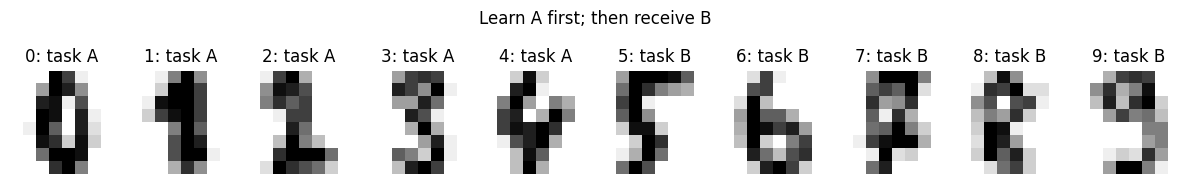

In [3]:
# Run this entire cell in Google Colab. No GPU or dataset download needed.
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# Try changing this to 0, 2, 10, or 30, then rerun the whole cell.
MEMORY_PER_DIGIT = 10 # save ten old training images for each old digit.
EPOCHS_A = 50 # train on task A for 50 passes
EPOCHS_B = 50 # training intervals for task B.

# 1. Old task A: recognize digits 0-4. New task B: recognize digits 5-9.
# The classifier always chooses among ALL TEN digits (no task ID at test time).
digits = load_digits()
X = digits.data / 16.0  # Pixel values scaled to [0, 1].
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)


XA, yA = X_train[y_train < 5], y_train[y_train < 5]
TA, a  = X_test[y_test < 5], y_test[y_test < 5]

XB, yB = X_train[y_train >= 5], y_train[y_train >= 5]
TB, b = X_test[y_test >= 5], y_test[y_test >= 5]

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for digit, ax in enumerate(axes):
    ax.imshow(X_train[y_train == digit][0].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'{digit}: task {"A" if digit < 5 else "B"}')
    ax.axis('off')
plt.suptitle('Learn A first; then receive B')
plt.tight_layout()
plt.show()


In [5]:

# partial_fit updates existing weights; it does not restart training.
model = MLPClassifier(hidden_layer_sizes=(64,52, 335), activation='relu',
                      solver='adam', learning_rate_init=0.002,
                      batch_size=64, random_state=42)


In [ ]:
def accuracy(m):
    # Held-out examples are ONLY evaluated; never trained on or replayed.
    return [100 * m.score(TA, a), 100 * m.score(TB, b)]

history_A = [] #Creates an empty list in which we will store accuracy measurements.
for epoch in range(EPOCHS_A):
    model.partial_fit(XA, yA, classes=np.arange(10))
    history_A.append(accuracy(model))
before = np.array(history_A[-1]) #convert it into a N.array and save it as
                                 #the accuracy immediately before task B begins.

# 2. All strategies start from exactly the same trained model so create three independent copies.
models = {name: copy.deepcopy(model) for name in
          ['Frozen', 'New data only', 'Replay']}
histories = {name: list(history_A) for name in models} #Creates a separate accuracy-history list for each strategy,
                                                       #initially containing the shared task-A history

# Store a small, balanced memory from OLD TRAINING data only.
# selects ten training examples for each old digit
rng = np.random.default_rng(123)
indices = np.concatenate([
    rng.choice(
        np.flatnonzero(yA == digit),
        MEMORY_PER_DIGIT,
        replace=False)
    for digit in range(5)
])

MX, my = XA[indices], yA[indices]

# Match the number of updates and batch sizes for the two training strategies.
# Replay spends half of each batch on remembered old examples.
batch_rng = np.random.default_rng(456)
steps = int(np.ceil(len(XB) / 64))
for epoch in range(EPOCHS_B):
    for step in range(steps):
        new_indices = batch_rng.integers(len(XB), size=64)
        nx, ny = XB[new_indices], yB[new_indices]
        models['New data only'].partial_fit(nx, ny)
        if len(MX):
            old_indices = batch_rng.integers(len(MX), size=32)
            rx = np.concatenate([nx[:32], MX[old_indices]])
            ry = np.concatenate([ny[:32], my[old_indices]])
            models['Replay'].partial_fit(rx, ry)
        else:
            models['Replay'].partial_fit(nx, ny)
    for name, m in models.items():
        histories[name].append(accuracy(m))

# 3. Watch old-task retention and new-task learning over time.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (name, history) in zip(axes, histories.items()):
    h = np.array(history)
    ax.plot(np.arange(1, len(h)+1), h[:, 0], label='Old task A: digits 0-4', lw=2)
    ax.plot(np.arange(1, len(h)+1), h[:, 1], label='New task B: digits 5-9', lw=2)
    ax.axvline(EPOCHS_A + 0.5, color='black', linestyle='--')
    ax.axvspan(EPOCHS_A + 0.5, EPOCHS_A + EPOCHS_B, color='gray', alpha=0.08)
    ax.set(title=name, xlabel='Epoch / evaluation interval', ylim=(0, 103))
    ax.grid(alpha=0.2)
    ax.legend(loc='lower left', fontsize=8)
axes[0].set_ylabel('Held-out accuracy (%)')
fig.suptitle('Dashed line: task A ends and task B arrives', fontsize=14)
plt.tight_layout()
plt.show()

print(f'After learning A: old-task accuracy = {before[0]:.1f}%, '
      f'new-task accuracy = {before[1]:.1f}%')
print(f'Replay memory: {len(MX)} old training examples\n')
print(f'{"Strategy":<18} {"Old A (%)":>10} {"New B (%)":>10} {"A drop (pp)":>12}')
for name, history in histories.items():
    end = np.array(history[-1])
    print(f'{name:<18} {end[0]:>10.1f} {end[1]:>10.1f} {before[0]-end[0]:>12.1f}')
print('\nA drop = A accuracy before B minus A accuracy after B, in percentage points.')
print('Frozen: retains old skills but cannot learn B.')
print('New data only: learns B but may catastrophically forget A.')
print('Replay: uses old examples to help learn B while retaining A.')


## Read the plots

- **Plasticity:** the new-task curve rises after the dashed line.
- **Stability:** the old-task curve stays high after the dashed line.
- **Catastrophic forgetting:** old-task accuracy collapses while the model learns B.
- **Replay:** old examples keep the old task represented in weight updates, reducing forgetting.

The frozen model illustrates why retaining old knowledge alone is insufficient: it does not learn the new task. Replay is one continual-learning method; continual learning is the broader goal.

**Try it:** set `MEMORY_PER_DIGIT` to `0`, `2`, `10`, or `30`, then rerun the entire code cell. With zero memory, Replay receives exactly the same batches as New data only. More memory need not improve every metric monotonically in a single run.

**How fair is the comparison?** Both trainable models use the same architecture, starting weights, number of updates, and batch size. Replay replaces half the new examples in each batch with old ones, so it sees fewer new examples per update. This makes the allocation between new learning and retention explicit.

**Limits:** this deliberately simple two-task example makes interference visible; it is not a claim that all sequential training forgets this severely. Results can vary with library versions. Replay also requires storing old examples. The displayed A drop measures before-versus-after accuracy, not every possible formal forgetting metric. The original “learn + retain − forget” expression is a conceptual description, not the training loss used here.
